# **FRAP Analysis Pipeline**
---



# **Prepare environment and load dependencies**

### **Install python packages**

In [1]:
!pip3 install --upgrade pip
!pip install czitools
!pip install pylibCZIrw
!pip install aicsimageio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.1/739.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 88.7 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5034 sha256=7158d7f502e18fbf1e270bd631bb736f43fc40c92b43b8e8d4602fdd75e24585
  Stored in directory: /root/.cache/pip/wheels/71/c1

### **Download last version of analysis code from repository**

In [2]:
!git clone https://github.com/amarcosv/FRAP-analysis-younglab -b develop
%cd /content/FRAP-analysis-younglab/
%ls
!git pull origin develop
%cd /content/FRAP-analysis-younglab/src

Cloning into 'FRAP-analysis-younglab'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 108 (delta 12), reused 22 (delta 5), pack-reused 77 (from 1)
Receiving objects: 100% (108/108), 105.23 MiB | 18.02 MiB/s, done.
Resolving deltas: 100% (45/45), done.
Updating files: 100% (21/21), done.
/content/FRAP-analysis-younglab
env/  README.md  sample_images/  src/
From https://github.com/amarcosv/FRAP-analysis-younglab
 * branch            develop    -> FETCH_HEAD
Already up to date.
/content/FRAP-analysis-younglab/src


## **Import libraries**

In [3]:
import sys
sys.path.append('/content/FRAP-analysis-younglab/src/tools')
import frap_tools
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import os
from skimage.color import label2rgb

# **Mount Google Drive**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Run analysis

## **Define input folder**

In [6]:

#@markdown ###Path to training images:
Input_file = "//content/FRAP-analysis-younglab/sample_images/dish1_MECP2WT-#roi-03-Airyscan Processing-03.czi" #@param {type:"string"}

#@markdown ###Advanced Parameters

Use_Whole_cell = False #@param {type:"boolean"}
#Exp_fit_order = True #@param {type:"boolean"}

if os.path.exists(Input_file):
        print(f"Input file '{Input_file}' loaded correctly.")
else:
        print(f"ERROR: The file '{Input_file}' does not exist.")

imPath = Input_file
filename = os.path.basename(imPath.split('.czi')[0])



Input file '//content/FRAP-analysis-younglab/sample_images/dish1_MECP2WT-#roi-03-Airyscan Processing-03.czi' loaded correctly.


## Launch analysis and print results

In [7]:
#Load file
roiData,regions, image, frap_experiment = frap_tools.import_FRAP_data(imPath, True)
#Run analysis
roiData, frap_experiment = frap_tools.run_FRAP_analysis(roiData, frap_experiment, 1)

#Print results
print('\nFRAP results:')
if frap_experiment['recovery_model'].item()==1:
    print('\tHalf maximum = ' + str(frap_experiment['half_max'].item()) + ' [s]')
else:
    print('\tHalf maximum slow = ' + str(frap_experiment['half_max'].item()[0]) + ' [s]')
    print('\tHalf maximum fast = ' + str(frap_experiment['half_max'].item()[1]) + ' [s]')

print('\tBleach depth ' + str(frap_experiment['bleach_depth'].item()))
print('\tGap Ratio= ' + str(frap_experiment['gap_ratio'].item()))
print('\tMobile Fraction (uncorrected) = ' + str(frap_experiment['mob_corr'].item()) + ' (' + str(frap_experiment['mob'].item()) + ')')



[load_image_data] Loading dataset with dimensions: {'T': (0, 120), 'Z': (0, 1), 'C': (0, 1), 'X': (0, 332), 'Y': (0, 332)}


Reading sublocks planes: 0 2Dplanes [00:00, ? 2Dplanes/s]

[photobleaching_corr] Calculating photobleaching from imaging using control_wcell reference region
	using data from frame 20 onwards (10 after roi bleaching)
[np.float64(331.98584331258843), np.float64(51.97662370406982), 0.05]
([np.float64(165.99292165629421), np.float64(25.98831185203491), 0], [np.float64(663.9716866251769), np.float64(77.96493555610473), 10])
Fit results:
	offset = 316.8817075131472
	amplitude: 25.98831185204255
	tau: 0.05876627906283435
	Fitting error (r2)= 0.31293284988280723
	Fitting goodness (chi2)= 1.030927835051546
	Fitting significance (p-value)= 0.39705717859648915
Fitting recovery model
Fit results:
	offset = 0.880451830966355
	amplitude: -0.6340585748329379
	tau: 1.4589226816866885
	Fitting error (r2)= 0.8692234644130679
	Fitting goodness (chi2)= 1.0280373831775698
	Fitting significance (p-value)= 0.40180520234178985

FRAP results:
	Half maximum = 0.47510892061708476 [s]
	Bleach depth 0.17947313043248306
	Gap Ratio= 0.891642398250796
	Mobile Fraction (unco

# **Plot step-by-step results**

First load data and show raw intensities and cell ROIs selected by user and cell segmentation if applies

Text(0.5, 0.98, 'dish1_MECP2WT-#roi-03-Airyscan Processing-03')

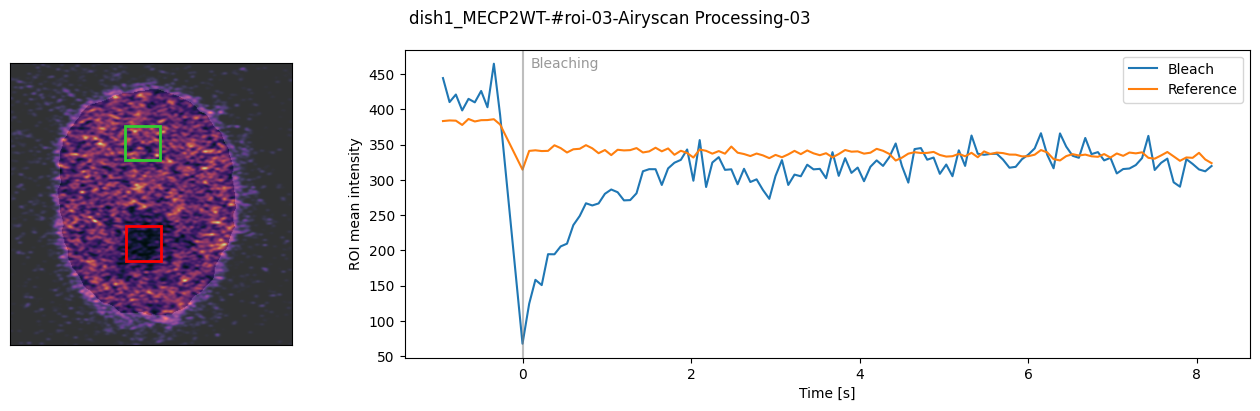

In [8]:
rect = patches.Rectangle((regions.X_roi[1], regions.Y_roi[1]), regions.Width_roi[1], regions.Height_roi[1], linewidth=2,
                         edgecolor=regions.Color[1], facecolor="none")

rect2 = patches.Rectangle((regions.X_roi[0], regions.Y_roi[0]), regions.Width_roi[0], regions.Height_roi[0], linewidth=2,
                         edgecolor=regions.Color[0], facecolor="none")


# Add the patch to the Axes
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(16, 4),width_ratios=[1, 3])

#Display sample image after photobleaching
ax[0].imshow(image[11,:,:],cmap='magma')

if frap_experiment.wcell_corr.item():
    mask = frap_experiment['wcellMask'].values[0]
    ax[0].imshow(mask.astype(int), cmap='Greens', alpha=0.2)

ax[0].add_patch(rect)
ax[0].add_patch(rect2)
ax[0].axes.get_xaxis().set_ticks([])
ax[0].axes.get_yaxis().set_ticks([])

#Plot raw and bleaching corrected data
ax[1].plot(roiData['timestamp_frap'],roiData['bleach'])
ax[1].plot(roiData['timestamp_frap'],roiData['reference'])
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
#ax[1].plot(roiData['timestamp_frap'],roiData['bleach_photo_corr'])
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_photo_corr'])
ax[1].legend(['Bleach', 'Reference'])
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('ROI mean intensity')
plt.axvline(0, color = 'tab:gray', alpha = 0.5)
plt.text(0.1,ax[1].get_ylim()[1]-10,'Bleaching',rotation=0, verticalalignment = 'top', color = 'tab:gray', alpha = 0.8)
plt.suptitle(filename)

Fit photobleaching decay from imaging in the reference curve

Text(0, 0.5, 'residuals')

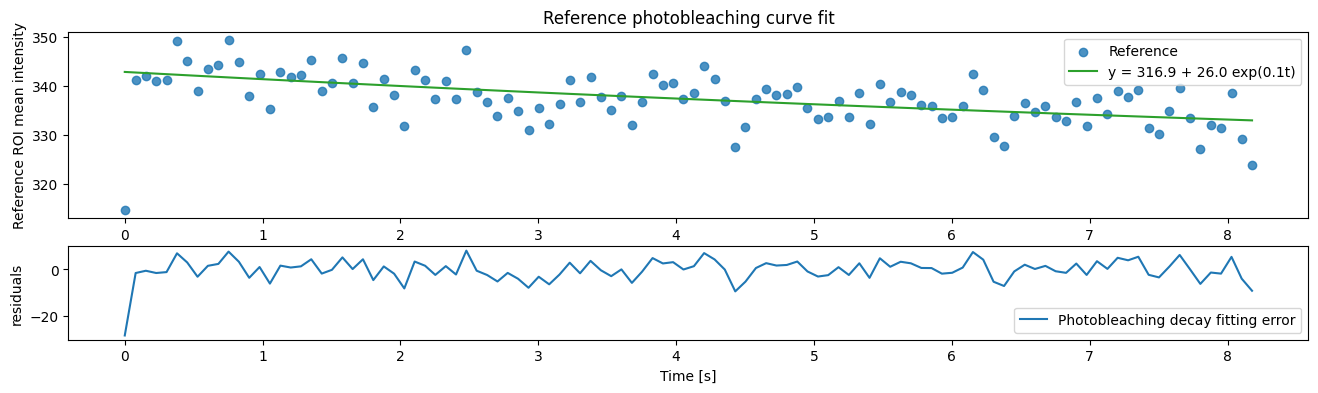

In [9]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(16, 4),height_ratios=[2,1])
#Plot photobleaching correction
ax[0].scatter(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],roiData['reference'].iloc[frap_experiment.bleach_frame.item() ::],
              alpha = 0.8, label = 'Reference')
#ax[2].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
ax[0].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],roiData['reference_synth'].iloc[frap_experiment.bleach_frame.item() ::],
           label = 'y = {0:0.1f} + {1:0.1f} exp({2:0.1f}t)'.format(frap_experiment['photobleach_fit'].item()[0], frap_experiment['photobleach_fit'].item()[1], frap_experiment['photobleach_fit'].item()[2]), color = 'tab:green' )
#ax[0].legend(['Reference', 'Decay fit'])
ax[0].legend()
ax[0].set_title('Reference photobleaching curve fit')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Reference ROI mean intensity')


#Plot photobleaching correction estimation error
ax[1].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['reference'].iloc[frap_experiment.bleach_frame.item() ::]-roiData['reference_decay_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[1].legend(['Photobleaching decay fitting error'])
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('residuals')
#plt.suptitle(filename)

Perform double normalization of FRAP curve

Text(0, 0.5, 'ROI mean intensity')

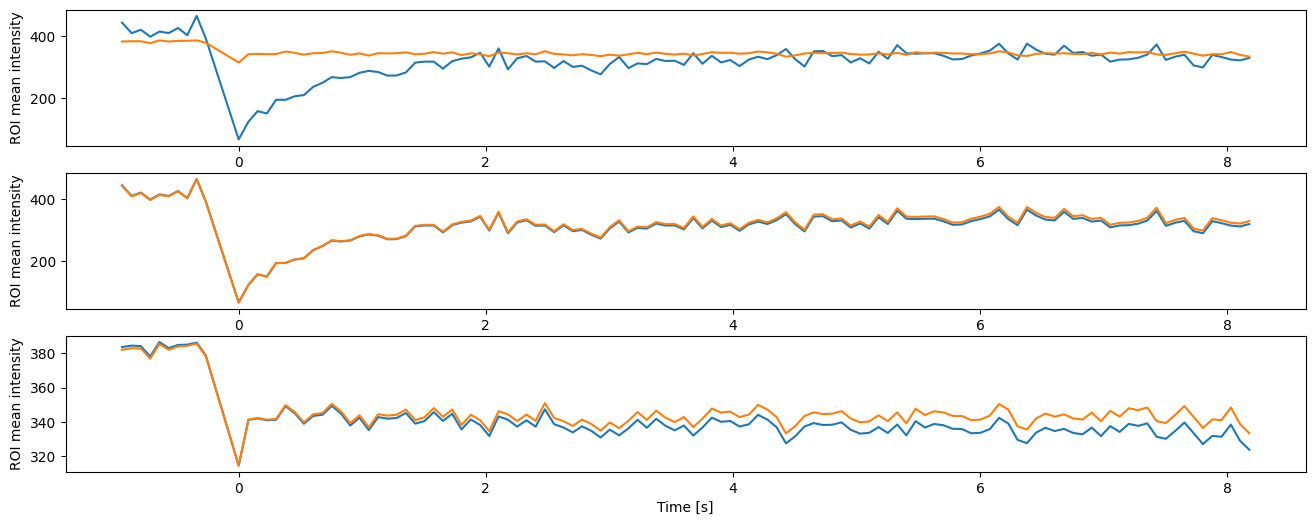

In [10]:
fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize=(16, 6))
#Plot raw and bleaching corrected data
ax[0].plot(roiData['timestamp_frap'],roiData['bleach_photo_corr'], label = 'Bleach')
ax[0].plot(roiData['timestamp_frap'],roiData['reference_photo_corr'], label = 'Reference')

ax[1].plot(roiData['timestamp_frap'],roiData['bleach'], label = 'Bleach raw')
ax[1].plot(roiData['timestamp_frap'],roiData['bleach_photo_corr'], label = 'Bleach corrected')
ax[2].plot(roiData['timestamp_frap'],roiData['reference'], label = 'Reference')
ax[2].plot(roiData['timestamp_frap'],roiData['reference_photo_corr'], label = 'Reference corrected')
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])


#ax[0].legend(['Bleach', 'Reference'])
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('ROI mean intensity')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('ROI mean intensity')
ax[2].set_xlabel('Time [s]')
ax[2].set_ylabel('ROI mean intensity')

In [ ]:
rect = patches.Rectangle((regions.X_roi[1], regions.Y_roi[1]), regions.Width_roi[1], regions.Height_roi[1], linewidth=2,
                         edgecolor=regions.Color[1], facecolor="none")

rect2 = patches.Rectangle((regions.X_roi[0], regions.Y_roi[0]), regions.Width_roi[0], regions.Height_roi[0], linewidth=2,
                         edgecolor=regions.Color[0], facecolor="none")


# Add the patch to the Axes
fig, ax = plt.subplots(6, figsize=(12, 16))

#Display sample image after photobleaching
ax[0].imshow(image[11,:,:],cmap='magma')

if frap_experiment.wcell_corr.item():
    mask = frap_experiment['wcellMask'].values[0]
    ax[0].imshow(mask.astype(int), cmap='Greens', alpha=0.2)

ax[0].add_patch(rect)
ax[0].add_patch(rect2)

#Plot raw and bleaching corrected data
ax[1].plot(roiData['timestamp_frap'],roiData['bleach'])
ax[1].plot(roiData['timestamp_frap'],roiData['reference'])
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
ax[1].plot(roiData['timestamp_frap'],roiData['bleach_photo_corr'])
ax[1].plot(roiData['timestamp_frap'],roiData['reference_photo_corr'])


ax[1].legend(['Bleach raw', 'Ctrl raw', 'Bleach corr', 'Ctrl corr'])

#Plot photobleaching correction
ax[2].plot(roiData['timestamp_frap'],roiData['reference'])
#ax[2].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
ax[2].plot(roiData['timestamp_frap'],roiData['reference_synth'])
ax[2].legend(['Reference', 'Synthetic decay fit'])

#Plot photobleaching correction estimation error
ax[3].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['reference'].iloc[frap_experiment.bleach_frame.item() ::]-roiData['reference_decay_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[3].legend(['Photobleaching decay fitting error'])


ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['bleach_recovery_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[4].scatter(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['frap_norm'].iloc[frap_experiment.bleach_frame.item() ::], s=5)
ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['frap_fullscale_norm'].iloc[frap_experiment.bleach_frame.item() ::])
ax[4].legend([ 'Recovery fit','FRAP normalized recovery', 'FRAP full scale norm'])
ax[4].legend(['Normalized recovery', 'Recovery fit','FRAP norm', 'FRAP full scale norm'])

ax[5].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
          roiData['frap_norm'].iloc[frap_experiment.bleach_frame.item() ::]-roiData['bleach_recovery_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[5].legend(['Decay model fitting error'])

plt.show()
